In [1]:
import numpy as np
import random
import os

SEED = 42
random.seed(SEED)

np.random.seed(SEED)

# OS-level (for reproducibility)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Finding only those common patients who has both ID number & Ultra Sound Image number

In [2]:
# =========================
# LOAD + MULTIMODAL COHORT + SPLIT
# =========================

import pandas as pd
import numpy as np
import os
import re

SEED = 42

file_path = r"D:\Ainur Apai\IEEE Riga\app_data.xlsx"
image_dir = r"D:\Ainur Apai\IEEE Riga\US_Pictures\US_Pictures"

df = pd.read_excel(file_path, sheet_name="All cases")

# --- Filtering
df = df.dropna(subset=["Diagnosis"])
df = df.dropna(subset=["US_Number"])
df["US_Number"] = df["US_Number"].astype(int)

# --- Target
df["Target"] = df["Diagnosis"].map({
    "appendicitis": 1,
    "no appendicitis": 0
})

# =========================
# INTERSECTION (578 patients)
# =========================

# Image patient IDs
image_patient_ids = []
for file in os.listdir(image_dir):
    match = re.match(r"(\d+)\.", file)
    if match:
        image_patient_ids.append(int(match.group(1)))

image_patients = set(image_patient_ids)
tabular_patients = set(df["US_Number"].unique())

common_patients = tabular_patients.intersection(image_patients)

print("Common patients:", len(common_patients))

# Keep only multimodal cohort
df = df[df["US_Number"].isin(common_patients)].copy()

print("Final dataset size:", len(df))

# =========================
# SPLIT 
# =========================

from sklearn.model_selection import train_test_split

train_patients, test_patients = train_test_split(
    df["US_Number"],
    test_size=0.2,
    stratify=df["Target"],
    random_state=SEED
)

df_train = df[df["US_Number"].isin(train_patients)].copy()
df_test  = df[df["US_Number"].isin(test_patients)].copy()

print("Train patients:", df_train["US_Number"].nunique())
print("Test patients:", df_test["US_Number"].nunique())

Common patients: 578
Final dataset size: 578
Train patients: 462
Test patients: 116


# Radiologist interpretation are removed (Diagnosis-related columns & Ultrasound-derived structured features)


In [3]:
# =========================
# STEP 1: Define columns to remove
# =========================

leakage_cols = [
    "Diagnosis",
    "Diagnosis_Presumptive",
    "Severity",
    "Management",
    "Length_of_Stay"
]

us_structured_cols = [
    "Appendix_on_US",
    "Appendix_Diameter",
    "Free_Fluids",
    "Appendix_Wall_Layers",
    "Target_Sign",
    "Appendicolith",
    "Perfusion",
    "Perforation",
    "Surrounding_Tissue_Reaction",
    "Appendicular_Abscess",
    "Abscess_Location",
    "Pathological_Lymph_Nodes",
    "Lymph_Nodes_Location",
    "Conglomerate_of_Bowel_Loops",
    "Ileus",
    "Coprostasis",
    "Meteorism",
    "Enteritis",
    "Gynecological_Findings",
    "US_Performed"
]

identifier_cols = ["US_Number"]

remove_cols = leakage_cols + us_structured_cols + identifier_cols


# =========================
# STEP 2: Split FIRST (CRITICAL)
# =========================

X = df.drop(columns=["Target"])
y = df["Target"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)


# =========================
# STEP 3: Remove leakage columns (AFTER split)
# =========================

X_train = X_train.drop(columns=remove_cols, errors="ignore")
X_test  = X_test.drop(columns=remove_cols, errors="ignore")


# =========================
# STEP 4: Final check
# =========================

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nFeatures:")
print(X_train.columns.tolist())

Train shape: (462, 32)
Test shape : (116, 32)

Features:
['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'Bowel_Wall_Thickening']


# HIGH MISSING REMOVAL

In [4]:
missing_percent = X_train.isnull().mean() * 100
high_missing_cols = missing_percent[missing_percent > 70].index.tolist()

print("Removing high-missing features:")
print(high_missing_cols)

X_train = X_train.drop(columns=high_missing_cols)
X_test  = X_test.drop(columns=high_missing_cols)

print("Updated shapes:")
print("Train:", X_train.shape)
print("Test :", X_test.shape)

Removing high-missing features:
['Segmented_Neutrophils', 'Bowel_Wall_Thickening']
Updated shapes:
Train: (462, 30)
Test : (116, 30)


# PREPROCESSING 

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ---- Feature type detection
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

# ---- Numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

# ---- Categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# ---- Full preprocessor
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready.")

Numeric features: 14
Categorical features: 16
Preprocessing pipeline ready.


C:\Users\User\AppData\Local\Temp\ipykernel_16644\1836032331.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "bool", "category"]).columns.tolist()


# MODEL

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=SEED
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=SEED
    )
}

In [7]:
# =========================
# TRAIN + EVALUATE
# =========================

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

results = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    probs = pipe.predict_proba(X_test)[:, 1]
    preds = pipe.predict(X_test)
    
    auc = roc_auc_score(y_test, probs)
    
    results[name] = auc
    
    print(f"\n===== {name} =====")
    print("AUC:", round(auc, 4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("Classification Report:\n", classification_report(y_test, preds))


===== LogisticRegression =====
AUC: 0.7979
Confusion Matrix:
 [[23 16]
 [11 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.59      0.63        39
           1       0.80      0.86      0.83        77

    accuracy                           0.77       116
   macro avg       0.74      0.72      0.73       116
weighted avg       0.76      0.77      0.76       116


===== RandomForest =====
AUC: 0.8388
Confusion Matrix:
 [[21 18]
 [ 6 71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.54      0.64        39
           1       0.80      0.92      0.86        77

    accuracy                           0.79       116
   macro avg       0.79      0.73      0.75       116
weighted avg       0.79      0.79      0.78       116


===== XGBoost =====
AUC: 0.8235
Confusion Matrix:
 [[24 15]
 [11 66]]
Classification Report:
               precision    recall  f1-score  

# OPTUNA

In [8]:
# OPTUNA (RF + XGB)
#%pip install optuna
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OPTUNA on  XGB

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

def objective_xgb(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10),
        "eval_metric": "logloss",
        "random_state": SEED,
        "use_label_encoder": False
    }

    model = XGBClassifier(**params)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    return scores.mean()
    

In [10]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=30)

print("Best XGB params:")
print(study_xgb.best_params)
print("Best CV AUC:", study_xgb.best_value)

[I 2026-06-14 02:58:57,227] A new study created in memory with name: no-name-48352667-8ead-4717-aa25-70028862d200
[I 2026-06-14 02:58:59,076] Trial 0 finished with value: 0.7846807244843997 and parameters: {'n_estimators': 464, 'max_depth': 8, 'learning_rate': 0.1147146984793744, 'subsample': 0.6911464869283053, 'colsample_bytree': 0.786929733098505, 'gamma': 3.201028098298005, 'reg_lambda': 2.3088574214443933}. Best is trial 0 with value: 0.7846807244843997.
[I 2026-06-14 02:59:00,687] Trial 1 finished with value: 0.790775383395029 and parameters: {'n_estimators': 118, 'max_depth': 6, 'learning_rate': 0.019076591374959657, 'subsample': 0.8349810591671354, 'colsample_bytree': 0.7554326439515168, 'gamma': 1.634858123702247, 'reg_lambda': 0.8768600015573866}. Best is trial 1 with value: 0.790775383395029.
[I 2026-06-14 02:59:02,468] Trial 2 finished with value: 0.7875594923320993 and parameters: {'n_estimators': 234, 'max_depth': 7, 'learning_rate': 0.03220766276123927, 'subsample': 0.79

Best XGB params:
{'n_estimators': 383, 'max_depth': 6, 'learning_rate': 0.04991167169969157, 'subsample': 0.983511116666947, 'colsample_bytree': 0.8033906664916209, 'gamma': 3.4559687883475925, 'reg_lambda': 6.824557105049354}
Best CV AUC: 0.812043892120571


# OPTUNA on Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

def objective_rf(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": SEED
    }

    model = RandomForestClassifier(**params)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    return scores.mean()

In [12]:
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=30)

print("Best RF params:")
print(study_rf.best_params)
print("Best CV AUC:", study_rf.best_value)

[I 2026-06-14 02:59:06,694] A new study created in memory with name: no-name-44c71276-a906-4850-9b20-8b0122a0fe19
[I 2026-06-14 02:59:07,227] Trial 0 finished with value: 0.7833190111052353 and parameters: {'n_estimators': 347, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7833190111052353.
[I 2026-06-14 02:59:07,709] Trial 1 finished with value: 0.7818945002644103 and parameters: {'n_estimators': 314, 'max_depth': 21, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7833190111052353.
[I 2026-06-14 02:59:07,943] Trial 2 finished with value: 0.7857218402961396 and parameters: {'n_estimators': 138, 'max_depth': 11, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 2 with value: 0.7857218402961396.
[I 2026-06-14 02:59:08,197] Trial 3 finished with value: 0.7820928080380751 and parameters: {'n_estimators': 179, 'max_depth': 10, 

Best RF params:
{'n_estimators': 378, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best CV AUC: 0.7871827075621365


# FINAL MODEL (Choosing the RF baseline because Hyperparameter optimization did not yield performance improvements )

In [13]:
# =========================
# FINAL MODEL (RF BASELINE)
# =========================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED
)

final_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", final_model)
])

# Train on full training data
final_pipeline.fit(X_train, y_train)

print("Final model trained (Random Forest baseline).")

Final model trained (Random Forest baseline).


===== TEST PERFORMANCE =====
AUC: 0.8388

Confusion Matrix:
 [[21 18]
 [ 6 71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.54      0.64        39
           1       0.80      0.92      0.86        77

    accuracy                           0.79       116
   macro avg       0.79      0.73      0.75       116
weighted avg       0.79      0.79      0.78       116


===== CROSS-VALIDATION =====
Mean AUC: 0.7791
Std AUC : 0.0307

===== 95% CONFIDENCE INTERVAL =====
CI: (0.7570, 0.9139)


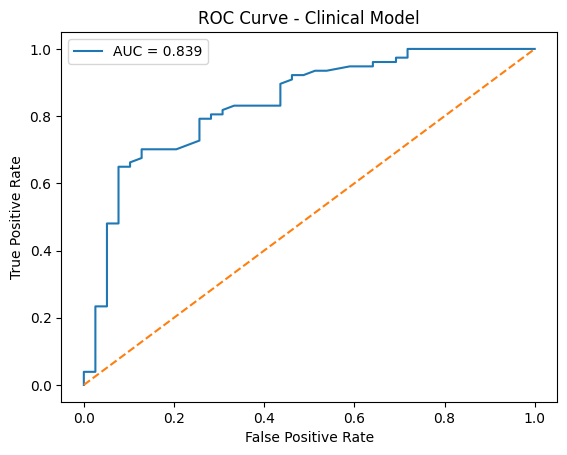


===== TOP FEATURES =====
num__WBC_Count: 0.1064
num__CRP: 0.0799
num__Neutrophil_Percentage: 0.0696
num__Alvarado_Score: 0.0579
num__Body_Temperature: 0.0505
num__Age: 0.0476
num__BMI: 0.0455
num__Thrombocyte_Count: 0.0451
num__Weight: 0.0430
num__RBC_Count: 0.0421
num__Paedriatic_Appendicitis_Score: 0.0411
num__Height: 0.0410
num__Hemoglobin: 0.0389
num__RDW: 0.0385
cat__Peritonitis_no: 0.0306


In [14]:
# =========================
# FINAL EVALUATION
# =========================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils import resample

# ---------- Test Prediction ----------
probs = final_pipeline.predict_proba(X_test)[:, 1]
preds = final_pipeline.predict(X_test)

test_auc = roc_auc_score(y_test, probs)

print("===== TEST PERFORMANCE =====")
print("AUC:", round(test_auc, 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))


# ---------- Cross-validation ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    final_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("\n===== CROSS-VALIDATION =====")
print("Mean AUC:", round(cv_scores.mean(), 4))
print("Std AUC :", round(cv_scores.std(), 4))


# ---------- Bootstrap CI ----------
auc_scores = []
for i in range(1000):
    X_bs, y_bs = resample(X_test, y_test, random_state=i)
    probs_bs = final_pipeline.predict_proba(X_bs)[:, 1]
    auc_scores.append(roc_auc_score(y_bs, probs_bs))

lower = np.percentile(auc_scores, 2.5)
upper = np.percentile(auc_scores, 97.5)

print("\n===== 95% CONFIDENCE INTERVAL =====")
print(f"CI: ({lower:.4f}, {upper:.4f})")


# ---------- ROC Curve ----------
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Clinical Model")
plt.legend()
plt.show()


# ---------- Feature Importance ----------
feature_names = final_pipeline.named_steps["prep"].get_feature_names_out()
importances = final_pipeline.named_steps["model"].feature_importances_

sorted_feats = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("\n===== TOP FEATURES =====")
for f, imp in sorted_feats[:15]:
    print(f"{f}: {imp:.4f}")

# Class-weight Random Forest to check if  imbalance  has  any  impact on  it  or  not.

In [15]:
# =========================
# CLASS-WEIGHT MODEL
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

cw_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=SEED
)

cw_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", cw_model)
])

cw_pipeline.fit(X_train, y_train)

probs_cw = cw_pipeline.predict_proba(X_test)[:, 1]
preds_cw = cw_pipeline.predict(X_test)

print("AUC (class-weight):", roc_auc_score(y_test, probs_cw))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds_cw))
print("\nClassification Report:\n", classification_report(y_test, preds_cw))

AUC (class-weight): 0.8393273393273393

Confusion Matrix:
 [[19 20]
 [ 4 73]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.49      0.61        39
           1       0.78      0.95      0.86        77

    accuracy                           0.79       116
   macro avg       0.81      0.72      0.74       116
weighted avg       0.80      0.79      0.78       116



# no improvement in performance, indicating that class imbalance was not a major limitation in this dataset.

# Feature permutation_importance

In [16]:
print(len(X_test.columns))
print(len(importances))

30
55


In [17]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:10])

55
['num__Age' 'num__BMI' 'num__Height' 'num__Weight' 'num__Alvarado_Score'
 'num__Paedriatic_Appendicitis_Score' 'num__Body_Temperature'
 'num__WBC_Count' 'num__Neutrophil_Percentage' 'num__RBC_Count']


In [18]:
feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

print(feat_df.head(30))

                                      feature  importance
7                              num__WBC_Count    0.106405
13                                   num__CRP    0.079867
8                  num__Neutrophil_Percentage    0.069555
4                         num__Alvarado_Score    0.057891
6                       num__Body_Temperature    0.050543
0                                    num__Age    0.047648
1                                    num__BMI    0.045501
12                     num__Thrombocyte_Count    0.045125
3                                 num__Weight    0.042967
9                              num__RBC_Count    0.042134
5          num__Paedriatic_Appendicitis_Score    0.041094
2                                 num__Height    0.041031
10                            num__Hemoglobin    0.038932
11                                   num__RDW    0.038544
50                        cat__Peritonitis_no    0.030590
49                     cat__Peritonitis_local    0.014186
21  cat__Contr

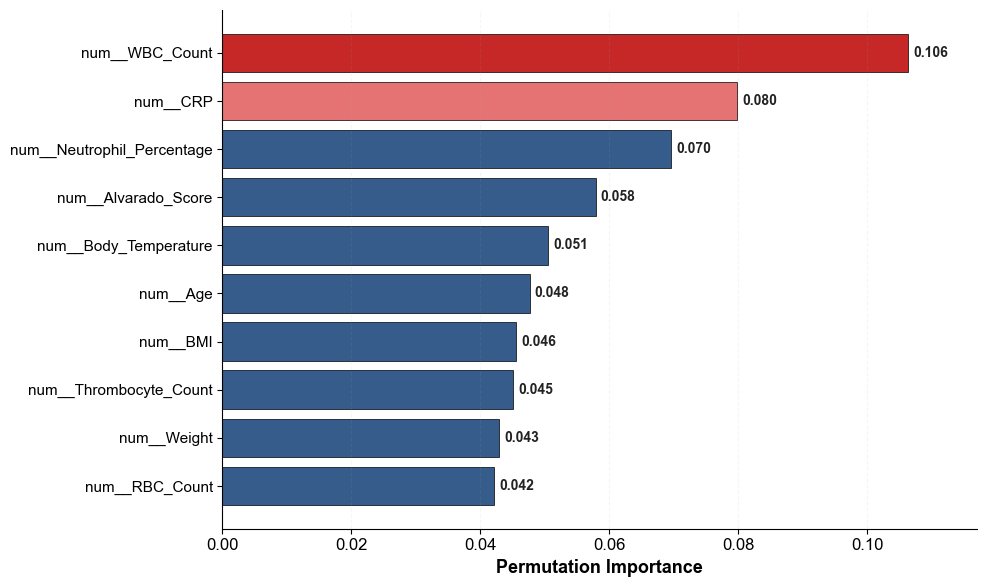

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# BUILD FEATURE IMPORTANCE DATAFRAME
# ==========================================================

feature_names = preprocessor.get_feature_names_out()

feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_df = (
    feat_df
    .sort_values("importance", ascending=False)
    .head(10)
)

# ==========================================================
# CLINICAL LABELS
# ==========================================================

rename_dict = {
    "CRP": "C-Reactive Protein (CRP)",
    "Peritonitis": "Peritonitis",
    "WBC_Count": "White Blood Cell Count",
    "Contralateral_Rebound_Tenderness": "Contralateral Rebound Tenderness",
    "Loss_of_Appetite": "Loss of Appetite",
    "Weight": "Weight",
    "BMI": "Body Mass Index",
    "Neutrophil_Percentage": "Neutrophil Percentage",
    "Thrombocyte_Count": "Platelet Count",
    "Height": "Height"
}

feat_df["feature"] = feat_df["feature"].replace(rename_dict)

# ==========================================================
# SORT FOR HORIZONTAL BARPLOT
# ==========================================================

feat_df = feat_df.sort_values(
    "importance",
    ascending=True
)

# ==========================================================
# COLORS
# ==========================================================

colors = ["#355C8A"] * len(feat_df)

# Top predictor
colors[-1] = "#C62828"   # CRP

# Second predictor
colors[-2] = "#E57373"   # Peritonitis

# ==========================================================
# STYLE
# ==========================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11
})

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor="white"
)

bars = ax.barh(
    feat_df["feature"],
    feat_df["importance"],
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

# ==========================================================
# VALUE LABELS
# ==========================================================

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 0.0008,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#222222"
    )

# ==========================================================
# AXES
# ==========================================================

ax.set_xlabel(
    "Permutation Importance",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel("")

ax.tick_params(
    axis="y",
    labelsize=11
)

ax.tick_params(
    axis="x",
    labelsize=12
)

# ==========================================================
# VISUAL CLEANUP
# ==========================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.10
)

# ==========================================================
# LIMITS
# ==========================================================

ax.set_xlim(
    0,
    feat_df["importance"].max() * 1.10
)

# ==========================================================
# SAVE
# ==========================================================

plt.tight_layout()

plt.savefig(
    "Figure4_Clinical_FeatureImportance_Nexus.png",
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "Figure4_Clinical_FeatureImportance_Nexus.pdf",
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

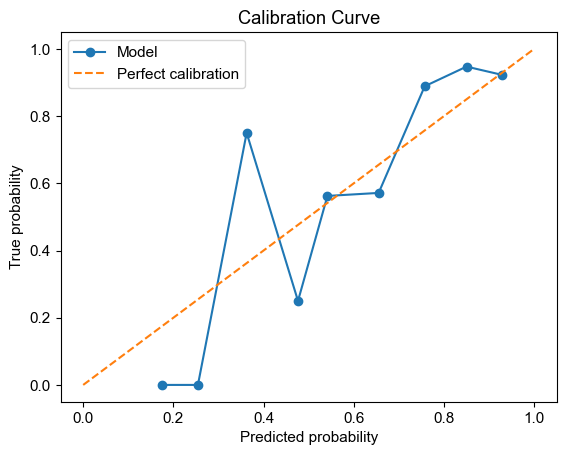

In [20]:
# =========================
# CALIBRATION CURVE
# =========================

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0,1], [0,1], linestyle='--', label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

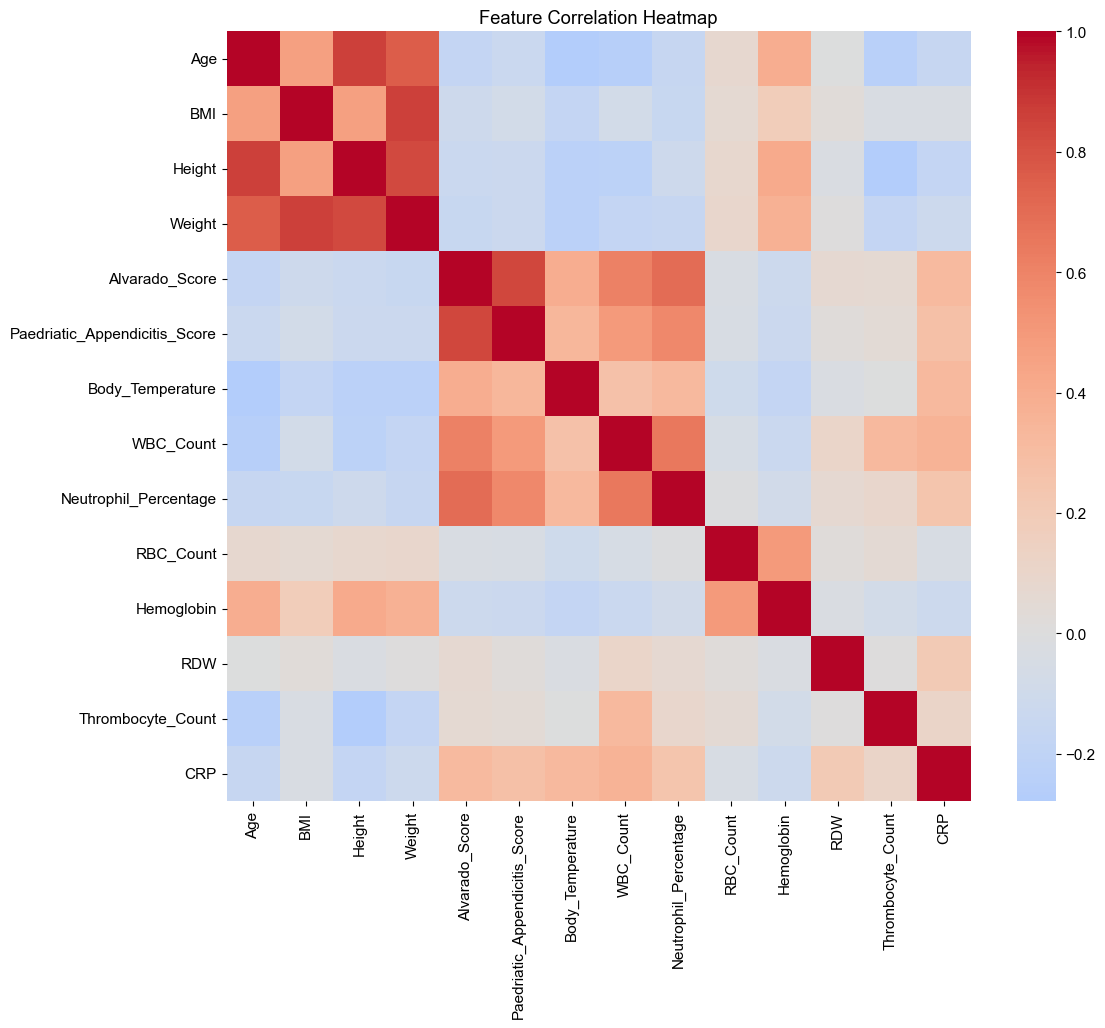

In [21]:
# =========================
# CORRELATION HEATMAP
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

corr = X_train.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Feature Correlation Heatmap")
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    preds_t = (probs > t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()
    
    sensitivity = tp / (tp + fn)   # recall positive
    specificity = tn / (tn + fp)   # recall negative
    
    results.append((t, sensitivity, specificity))


for t, sens, spec in results:
    print(f"Threshold={t:.2f} | Sensitivity={sens:.2f} | Specificity={spec:.2f}")

Threshold=0.10 | Sensitivity=1.00 | Specificity=0.00
Threshold=0.15 | Sensitivity=1.00 | Specificity=0.03
Threshold=0.20 | Sensitivity=1.00 | Specificity=0.13
Threshold=0.25 | Sensitivity=1.00 | Specificity=0.18
Threshold=0.30 | Sensitivity=1.00 | Specificity=0.28
Threshold=0.35 | Sensitivity=0.99 | Specificity=0.28
Threshold=0.40 | Sensitivity=0.96 | Specificity=0.31
Threshold=0.45 | Sensitivity=0.95 | Specificity=0.36
Threshold=0.50 | Sensitivity=0.92 | Specificity=0.54
Threshold=0.55 | Sensitivity=0.83 | Specificity=0.62
Threshold=0.60 | Sensitivity=0.81 | Specificity=0.72
Threshold=0.65 | Sensitivity=0.74 | Specificity=0.74
Threshold=0.70 | Sensitivity=0.70 | Specificity=0.87
Threshold=0.75 | Sensitivity=0.56 | Specificity=0.92
Threshold=0.80 | Sensitivity=0.39 | Specificity=0.95
Threshold=0.85 | Sensitivity=0.26 | Specificity=0.95


In [23]:
best_t = None
best_score = -1

for t, sens, spec in results:
    score = sens + spec - 1
    if score > best_score:
        best_score = score
        best_t = t

print("Best threshold:", best_t)

Best threshold: 0.7000000000000002


In [24]:
final_preds = (probs > best_t).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, final_preds))
print("\nClassification Report:\n", classification_report(y_test, final_preds))

Confusion Matrix:
 [[34  5]
 [23 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.87      0.71        39
           1       0.92      0.70      0.79        77

    accuracy                           0.76       116
   macro avg       0.76      0.79      0.75       116
weighted avg       0.81      0.76      0.77       116



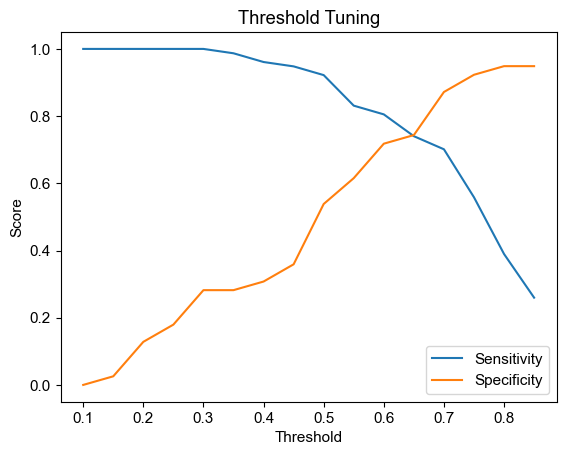

In [25]:
import matplotlib.pyplot as plt

ths = [r[0] for r in results]
sens = [r[1] for r in results]
spec = [r[2] for r in results]

plt.plot(ths, sens, label="Sensitivity")
plt.plot(ths, spec, label="Specificity")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

In [26]:
import pandas as pd
import numpy as np

# =========================
# Load dataset
# =========================
df = pd.read_excel(r"D:\Ainur Apai\IEEE Riga\app_data.xlsx")

# =========================
# Keep valid diagnosis only
# =========================
df = df[df["Diagnosis"].isin(["appendicitis", "no appendicitis"])].copy()

# =========================
# Age
# =========================
age_mean = df["Age"].mean()
age_sd = df["Age"].std()

# =========================
# BMI
# =========================
bmi_mean = df["BMI"].mean()
bmi_sd = df["BMI"].std()

# =========================
# Height
# =========================
height_mean = df["Height"].mean()
height_sd = df["Height"].std()

# =========================
# Weight
# =========================
weight_mean = df["Weight"].mean()
weight_sd = df["Weight"].std()

# =========================
# Sex distribution
# =========================
sex_counts = df["Sex"].value_counts()

male_n = sex_counts.get("male", 0)
female_n = sex_counts.get("female", 0)

total_n = len(df)

male_pct = male_n / total_n * 100
female_pct = female_n / total_n * 100

# =========================
# Diagnosis distribution
# =========================
dx_counts = df["Diagnosis"].value_counts()

app_n = dx_counts["appendicitis"]
nonapp_n = dx_counts["no appendicitis"]

app_pct = app_n / total_n * 100
nonapp_pct = nonapp_n / total_n * 100

# =========================
# Print Table 1 values
# =========================
print("="*50)
print("TABLE 1: COHORT CHARACTERISTICS")
print("="*50)

print(f"Total Patients: {total_n}")

print(f"\nAge (years): {age_mean:.2f} ± {age_sd:.2f}")

print(f"\nMale: {male_n} ({male_pct:.1f}%)")
print(f"Female: {female_n} ({female_pct:.1f}%)")

print(f"\nBMI: {bmi_mean:.2f} ± {bmi_sd:.2f}")

print(f"\nHeight (cm): {height_mean:.2f} ± {height_sd:.2f}")

print(f"\nWeight (kg): {weight_mean:.2f} ± {weight_sd:.2f}")

print(f"\nAppendicitis: {app_n} ({app_pct:.1f}%)")
print(f"No Appendicitis: {nonapp_n} ({nonapp_pct:.1f}%)")

print("="*50)

TABLE 1: COHORT CHARACTERISTICS
Total Patients: 780

Age (years): 11.34 ± 3.53

Male: 403 (51.7%)
Female: 376 (48.2%)

BMI: 18.91 ± 4.39

Height (cm): 148.00 ± 19.74

Weight (kg): 43.16 ± 17.40

Appendicitis: 463 (59.4%)
No Appendicitis: 317 (40.6%)


In [27]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, probs)
print("Clinical AUC =", auc)

Clinical AUC = 0.8388278388278388


In [28]:
clinical_probs = probs

print(len(y_test))
print(len(clinical_probs))

from sklearn.metrics import roc_auc_score

print(
    "Clinical AUC =",
    roc_auc_score(y_test, clinical_probs)
)

116
116
Clinical AUC = 0.8388278388278388
